In [1]:
import pandas as pd
from datetime import datetime

In [2]:
# Load Australian policy data
OxCGRT = pd.read_csv("../data/OxCGRT_AUS_latest.csv")
OxCGRT.shape

(9864, 61)

In [3]:
# Keep the columns relevant for mask mandate analysis
OxCGRT = OxCGRT[["RegionName", "RegionCode", "Date", "H6M_Facial Coverings"]].copy()

# Convert to datetime format
OxCGRT["Date"] = pd.to_datetime(OxCGRT["Date"], format="%Y%m%d")

OxCGRT.head()

,RegionName,RegionCode,Date,H6M_Facial Coverings
0,Australian Capital Territory,AUS_ACT,2020-01-01,0.0
1,Australian Capital Territory,AUS_ACT,2020-01-02,0.0
2,Australian Capital Territory,AUS_ACT,2020-01-03,0.0
3,Australian Capital Territory,AUS_ACT,2020-01-04,0.0
4,Australian Capital Territory,AUS_ACT,2020-01-05,0.0


In [4]:
# Sort the data by region and date
OxCGRT = OxCGRT.sort_values(["RegionName", "Date"]).reset_index(drop=True)

# Compute the 14-day rolling average
OxCGRT["facial_covering_14d_avg"] = (OxCGRT.groupby("RegionName")["H6M_Facial Coverings"].transform(lambda s: s.rolling(window=14).mean()))

OxCGRT.head()

,RegionName,RegionCode,Date,H6M_Facial Coverings,facial_covering_14d_avg
0,Australian Capital Territory,AUS_ACT,2020-01-01,0.0,NaN
1,Australian Capital Territory,AUS_ACT,2020-01-02,0.0,NaN
2,Australian Capital Territory,AUS_ACT,2020-01-03,0.0,NaN
3,Australian Capital Territory,AUS_ACT,2020-01-04,0.0,NaN
4,Australian Capital Territory,AUS_ACT,2020-01-05,0.0,NaN


In [5]:
# Get the first date when policy intensity ≥ 3 for each region
mandate_start_dates = (OxCGRT[OxCGRT["facial_covering_14d_avg"] >= 3].groupby("RegionName", as_index=False).first())

# Keep key columns only
mandate_start_dates = mandate_start_dates[
    ["RegionName", "RegionCode", "Date", "facial_covering_14d_avg"]
]

mandate_start_dates.head()

,RegionName,RegionCode,Date,facial_covering_14d_avg
0,Australian Capital Territory,AUS_ACT,2021-08-18,3.000000
1,New South Wales,AUS_NSW,2021-07-09,3.000000
2,Northern Territory,AUS_NT,2021-11-21,3.000000
3,Queensland,AUS_QLD,2021-01-17,3.142857
4,South Australia,AUS_SA,2021-07-26,3.000000


In [ ]:
# Save data
mandate_start_dates.to_csv("../data/mandate_start_dates.csv", index=False)

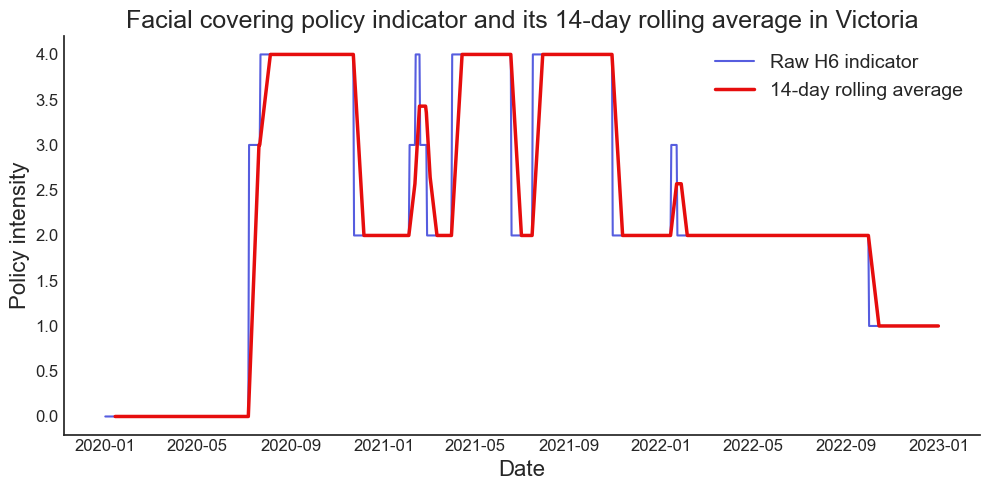

In [ ]:
# Plot raw and smoothed facial covering policy trends for Victoria

import matplotlib.pyplot as plt

df_plot = OxCGRT[OxCGRT["RegionName"] == "Victoria"].copy()
df_plot = df_plot.sort_values("Date")

# clean academic style
plt.style.use("seaborn-v0_8-white")

plt.figure(figsize=(10, 5))

# Raw H6
plt.plot(
    df_plot["Date"],
    df_plot["H6M_Facial Coverings"],
    color="#0e18d2",
    linewidth=1.5,
    alpha=0.7,
    label="Raw H6 indicator"
)

# Smoothed line
plt.plot(
    df_plot["Date"],
    df_plot["facial_covering_14d_avg"],
    color="#e60d0d",
    linewidth=2.5,
    label="14-day rolling average"
)

# Labels
plt.xlabel("Date", fontsize=16)
plt.ylabel("Policy intensity", fontsize=16)

# Title
plt.title(
    "Facial covering policy indicator and its 14-day rolling average in Victoria",
    fontsize=18
)

# Legend
plt.legend(frameon=False, fontsize=14)

# Remove top and right spines
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.show()